In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


# This is required to run multiple processes with JAX.
from multiprocessing import set_start_method
set_start_method('forkserver', force=True)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from pathlib import Path

print(jax.devices())
jax.config.update("jax_debug_nans", True)

from config import Config
import data

[CpuDevice(id=0)]


In [3]:
cfg = Config.from_file("/nas/cee-water/cjgleason/ted/swot-ml/runs/test/swot.yml")

In [4]:
cfg.quiet = False
cache_mgr = data.DynamicCacheManager(cfg)
train_cache_dir = cache_mgr.create_cache('train')

Caches will be stored at: /scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/_cache3/2fcd9841bcd04101
Calculating training statistics for encoding and normalization...


Indexing train:   0%|          | 0/1182 [00:00<?, ?it/s]/nas/cee-water/cjgleason/ted/swot-ml/src/data/cached_basingraphdataset.py:406: UserWarning: Error in ABOM-106786010: "No variable named 'width_river'. Variables on the dataset include ['tp_mean', 'sro_mean', 'sp_mean', 'discharge', 'd2m_mean', ..., 'ssrd_mean', 't2m_mean', 'e_mean', 'date', 'subbasin']"
  warnings.warn(f"Error in {basin_id}: {e}")
Indexing train:   0%|          | 1/1182 [00:22<7:19:03, 22.31s/it]/nas/cee-water/cjgleason/ted/swot-ml/src/data/cached_basingraphdataset.py:406: UserWarning: Error in ABOM-10418010: "No variable named 'width_river'. Variables on the dataset include ['tp_mean', 'sro_mean', 'sp_mean', 'discharge', 'd2m_mean', ..., 'ssrd_mean', 't2m_mean', 'e_mean', 'date', 'subbasin']"
  warnings.warn(f"Error in {basin_id}: {e}")
/nas/cee-water/cjgleason/ted/swot-ml/src/data/cached_basingraphdataset.py:406: UserWarning: Error in ABOM-132344010: "No variable named 'width_river'. Variables on the dataset inc

Wrote 308 new Zarr files.
✅ Saved 179862 indices to /scratch4/workspace/tlanghorst_umass_edu-swot-ml-zarr/zbs_batched/_cache3/2fcd9841bcd04101/train/_indices/sequence=90
All caches created and indexed.


False

In [5]:
import numpy as np
import xarray as xr
from jaxtyping import Array
from typing import NamedTuple
from tqdm import tqdm

class FlatObservationDataset(data.CachedBasinGraphDataset):
    """
    Fully in-memory flat observation dataset for MLP training.
    Caches dynamic, target, static features and metadata as flat arrays.
    """

    def __init__(self, cfg: Config, cache_dir: Path, pad_size: int, subset: str , source_name: str):
        super().__init__(cfg, cache_dir, subset)
        
        if source_name not in self.features.dynamic:
            raise ValueError(f"Source '{source_name}' not found in config dynamic sources.")
        self.source_name = source_name
        self.source_columns = self.features.dynamic[source_name]

        # --- Pre-load everything we need into memory as flat arrays ---
        self.samples = []

        for basin, subbasins in tqdm(self.basin_subset_dict.items(), desc="Caching basins in memory"):
            if not (self.cache_dir / basin).is_dir():
                print(f"{basin} not found in cache")
                continue
                
            with xr.open_zarr(self.cache_dir / basin, consolidated=True) as basin_ds:
                ds = basin_ds.sel(subbasin=basin_ds['subbasin'].isin(list(subbasins)))
                
                # Skip basins without required variables
                if not all(col in ds.data_vars for col in self.source_columns):
                    continue
                target_var = self.target[0]
                if target_var not in ds.data_vars:
                    continue

                ds = ds.load()
            
                x_dynamic = ds[self.source_columns]  # keep as DataArray for coords
                y = ds[self.target]
            
                valid_features = ~np.isnan(x_dynamic[self.source_columns[0]].values)
                valid_target = ~np.isnan(y.to_array().values[0,...])
                valid_mask = valid_features & valid_target
        
                for s_idx in range(valid_mask.shape[1]):
                    t_ids = np.where(valid_mask[:,s_idx])[0]
                    if len(t_ids) == 0:
                        continue
                    else:
                        subbasin_id = x_dynamic.subbasin.values[s_idx]
                        x_d = x_dynamic.isel(date=t_ids, subbasin=s_idx).to_array().values.T
                        n_samples, n_features = x_d.shape
                
                        if n_samples > pad_size:
                            raise ValueError(
                                f"increase pad_size ({pad_size}) to be greater than the number of samples ({n_samples} in current reach)"
                            )
                            
                        x_pad = np.zeros((pad_size, n_features), dtype=x_d.dtype)
                        x_pad[:n_samples, :] = x_d
                        mask = np.zeros((pad_size, n_features), dtype=np.int8)
                        mask[:n_samples, :] = 1
        
                        x_s = self.x_s.sel(subbasin=subbasin_id)[self.features.static].to_array().values
                        
                        y_arr = y.isel(date=t_ids, subbasin=s_idx).to_array().values.T
                        n_labels, n_targets = y_arr.shape
                        y_pad = np.zeros((pad_size, n_targets), dtype=x_d.dtype)
                        y_pad[:n_labels, :] = y_arr

                        assert n_labels == n_samples
                        
                        hws_cols = ['d_wse_river', 'width_river', 'slope_river']
                        hws_arr = x_dynamic[hws_cols].isel(date=t_ids, subbasin=s_idx).to_array().values.T
                        for i, col in enumerate(hws_cols):
                            hws_arr[:,i] = self.denormalize(hws_arr[:,i], col)
                            
                        n_samples, n_features = hws_arr.shape
                        hws_pad = np.zeros((pad_size, n_features), dtype=x_d.dtype)
                        hws_pad[:n_samples, :] = hws_arr
                       

                        reach_sample = {
                            'basin': basin,
                            'subbasin': subbasin_id,
                            'x_d': x_pad,
                            'd_mask': mask,
                            'x_s': x_s,
                            'hws': hws_pad,
                            'y': y_pad 
                        }
                        self.samples.append(reach_sample)

        
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int):
        return self.samples[idx]
        

train_dataset = FlatObservationDataset(cfg, train_cache_dir, 200, 'train', 'swot-river')

Calculating training statistics for encoding and normalization...
Loading basin graphs...Done!
Loading optimized indices for train...Done!


Caching basins in memory:   0%|          | 0/1182 [00:00<?, ?it/s]

ABOM-10418010 not found in cache
ABOM-106786010 not found in cache
ABOM-113129010 not found in cache
ABOM-117406010 not found in cache


Caching basins in memory:   0%|          | 5/1182 [00:01<03:58,  4.93it/s]

ABOM-117757010 not found in cache
ABOM-117806010 not found in cache


...

USGS-15304010 not found in cache


Caching basins in memory:  99%|█████████▊| 1167/1182 [04:13<00:08,  1.68it/s]

USGS-265501080364900 not found in cache
USGS-50011200 not found in cache
USGS-50014800 not found in cache
USGS-50027600 not found in cache
USGS-50037000 not found in cache
USGS-50039500 not found in cache
USGS-50046000 not found in cache
USGS-50047850 not found in cache
USGS-50049100 not found in cache


Caching basins in memory: 100%|██████████| 1182/1182 [04:13<00:00,  4.66it/s]

USGS-50075500 not found in cache
USGS-50111500 not found in cache
USGS-50138000 not found in cache
USGS-50144000 not found in cache
USGS-50147800 not found in cache


In [6]:
from torch.utils.data import DataLoader

def collate_flat_jax(samples):
    basin = [s['basin'] for s in samples]
    subbasin = [s['subbasin'] for s in samples]
    x_d = jnp.array([s['x_d'] for s in samples])
    d_mask = jnp.array([s['d_mask'] for s in samples])
    x_s = jnp.array([s['x_s'] for s in samples])
    hws = jnp.array([s['hws'] for s in samples])
    y = jnp.array([s['y'] for s in samples])
    return basin, subbasin, x_d, d_mask, x_s, hws, y

# train_dataset = FlatObservationDataset(cfg, train_cache_dir, 'train', 'swot-river')
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_flat_jax)

In [7]:
sample = train_dataset[0]

d_size = sample['x_d'].shape[1]
s_size = sample['x_s'].shape[0]

in_size = d_size + s_size
out_size = 1

In [28]:
for basin, subbasin, x_d, d_mask, x_s, hws, y in train_loader:
    break

x_d.shape

(8, 200, 33)

(8, 200, 536)

In [32]:
d_mask.shape

(8, 200, 33)

In [8]:
import jax
import jax.numpy as jnp
import equinox as eqx

class ReachParameterNet(eqx.Module):
    A0n_net: eqx.nn.MLP

    def __init__(self, in_size, hidden_size, depth, *, key):
        self.A0n_net = eqx.nn.MLP(
            in_size = in_size, 
            out_size = 2, 
            width_size = hidden_size, 
            depth = depth, 
            key=key
        )

    def concat_A0n_net(self, x_d, x_s):
            x = jnp.concat([x_d, x_s])
            return self.A0n_net(x)
    
    def __call__(self, x_d, d_mask, x_s, hws):
        # vmap across time dimension
        embeddings = jax.vmap(self.concat_A0n_net, in_axes=(0, None))(x_d, x_s)

        # Prevents padding from biasing the static parameter estimation
        reach_summary = jnp.mean(embeddings, axis=0, where=d_mask[:,None])

        # A0 Must be positive; exp ensures scale invariance
        A0 = jnp.exp(reach_summary[0])
        # Manning's n constrained to [0.01, 0.15] range
        n = jax.nn.sigmoid(reach_summary[1]) * 0.14 + 0.01

        dh = hws[:, 0]
        w = hws[:, 1]
        s = hws[:, 2]

        # rectangular approximation of dA while forcing A to be positive.
        A = A0 + (w * dh)
        eps = 1e-6
        A = eps + jax.nn.softplus(A)

        Q = (1/n) * A**(5/3) * w**(-2/3) * s**(1/2)
        
        return Q, A0, n


@eqx.filter_value_and_grad
def mse_loss(model, x_d, d_mask, x_s, hws, y):
    y_hat, _, _ = jax.vmap(model)(x_d, d_mask, x_s, hws)
    return jnp.nanmean((y_hat - y)**2, where=d_mask)
    


In [94]:
for batch in train_loader:
    basin, subbasin, x_d, d_mask, x_s, hws, y = batch
    d_mask = d_mask[..., 0] #bandaid
    y = y[...,0]

key = jax.random.PRNGKey(0)
model = ReachParameterNet(in_size, 128, 2, key=key)

y_hat, A0, n = jax.vmap(model)(x_d, d_mask, x_s, hws)
jnp.nanmean((y_hat - y)**2, where=d_mask)

Array(1097.8015, dtype=float32)

In [9]:
import optax
jax.config.update("jax_debug_nans", True)

key = jax.random.PRNGKey(0)
model = ReachParameterNet(in_size, 128, 2, key=key)

optim = optax.adam(0.0001)
trainable_model = eqx.filter(model, eqx.is_array)
opt_state = optim.init(trainable_model)


@eqx.filter_jit
def make_step(model, x_d, d_mask, x_s, hws, y, opt_state):
    loss, grads = mse_loss(model, x_d, d_mask, x_s, hws, y)
    updates, opt_state = optim.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state


losses = []
epoch_iter = tqdm(range(10000), desc='Epoch:')
for epoch in epoch_iter:
    e_losses = []
    for batch in train_loader:
        basin, subbasin, x_d, d_mask, x_s, hws, y = batch
        d_mask = d_mask[..., 0] #bandaid
        y = y[...,0]
        
        loss, model, opt_state = make_step(model, x_d, d_mask, x_s, hws, y, opt_state)
        e_losses.append(loss.item())
        
    
    loss = np.mean(e_losses)
    losses.append(loss)

    epoch_iter.set_postfix_str(f"{loss = :0.4f}")

    # if epoch % 50 == 0:
    #     print(f"{epoch = }, {loss = :0.4f}")


Epoch::   0%|          | 0/10000 [00:00<?, ?it/s]


FloatingPointError: invalid value (nan) encountered in convert_element_type

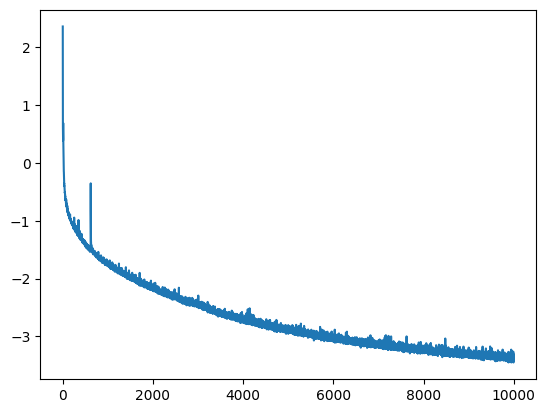

In [50]:
plt.plot(losses)

In [40]:
test_cache_dir = cache_mgr.create_cache('test')
test_dataset = FlatObservationDataset(cfg, test_cache_dir, 'test', 'swot-river')
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=True, collate_fn=collate_flat_jax)

Indices for test already exist. Skipping.
Calculating training statistics for encoding and normalization...
Loading basin graphs...Done!
Loading optimized indices for test...Done!


Caching basins in memory: 100%|██████████| 720/720 [09:18<00:00,  1.29it/s]

✅ Cached 10867 valid observation points in memory.


In [52]:
results

,subbasin,date,y,y_pred,y_pred_std
0,BRANA-16460000,2024-06-26T00:00:00.000000000,2148.070068,1196.576050,16.355427
1,EAUF-H1501010,2024-02-27T00:00:00.000000000,154.580017,356.848541,3.703883
2,USGS-06337000,2024-07-14T00:00:00.000000000,1.194971,58.574974,0.547321
3,BRANA-60680000,2024-12-08T00:00:00.000000000,179.183960,70.312370,0.595802
4,USGS-03192000,2024-01-18T00:00:00.000000000,126.009956,356.545593,20.441799
...,...,...,...,...,...
10862,ECCC-08EF001,2024-01-09T00:00:00.000000000,201.999954,84.041397,0.677484
10863,USGS-14359000,2023-05-11T00:00:00.000000000,128.558426,108.029938,2.053008
10864,ECCC-04FA001,2024-06-13T00:00:00.000000000,329.538147,665.117737,7.522882
10865,USGS-12322001,2024-01-20T00:00:00.000000000,158.291199,196.146851,2.392207


In [53]:

results.to_parquet('/nas/cee-water/cjgleason/ted/swot-ml/notebooks/multigraph_manual/tests/mlp_gmm_results.parquet')

In [54]:
results = pd.read_parquet('/nas/cee-water/cjgleason/ted/swot-ml/notebooks/multigraph_manual/tests/mlp_gmm_results.parquet')
results.sort_values('date', inplace=True)

In [55]:
import evaluate

def group_kge(grp):
    y = grp['y']
    y_hat = grp['y_pred']

    kge_results = evaluate.metrics.calc_kge(y, y_hat)
    if isinstance(kge_results, tuple):
        kge, corr, alpha, beta = kge_results
    else:
        kge = corr = alpha = beta = np.nan

    return kge

kge = results.groupby('subbasin').apply(group_kge, include_groups=False)

/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [56]:
kge

subbasin
ABOM-100288010    -5.112577
ABOM-123774010     0.110621
ABOM-132966010    -0.055989
ABOM-133073010    -0.484431
ABOM-133163010    -0.110141
                    ...    
USGS-15300500      0.171657
USGS-15304000      0.449244
USGS-15348000    -12.277418
USGS-15564900      0.894597
USGS-15747000      0.081239
Length: 681, dtype: float64

In [57]:
np.nanmedian(kge)

0.14802312814100316

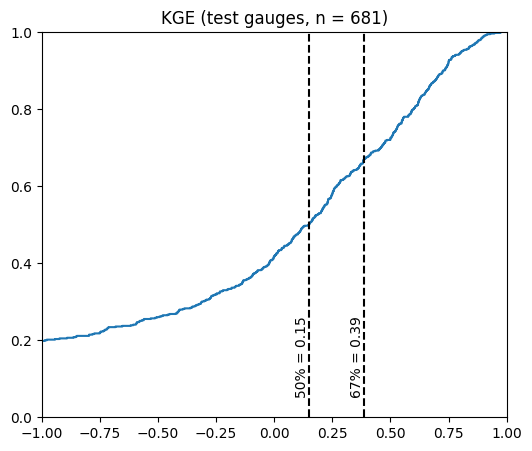

In [58]:
fig, ax = plt.subplots(figsize=(6,5))

kge_clean = kge.dropna().values

plt.ecdf(kge_clean)
plt.xlim([-1, 1])
plt.title(f"KGE (test gauges, n = {len(kge)})")

q50 = np.quantile(kge_clean, 0.50)
plt.axvline(q50, color='k', linestyle="--")
plt.text(q50, 0.05, f"50% = {q50:.2f}", rotation=90, va="bottom", ha="right")

q67 = np.quantile(kge_clean, 0.67)
plt.axvline(q67, color='k', linestyle="--")
plt.text(q67, 0.05, f"67% = {q67:.2f}", rotation=90, va="bottom", ha="right")

plt.show()
fig.savefig('/nas/cee-water/cjgleason/ted/swot-ml/notebooks/multigraph_manual/tests/MLP_GMM_KGE.png', dpi=300)

In [8]:
counts = results.groupby('subbasin').apply(len, include_groups=False).sort_values()

counts[counts>10]

subbasin
ECCC-05DE010       11
USGS-05586100      11
USGS-12031000      11
EAUF-K2790810      11
BRANA-54710000     11
                 ... 
EAUF-M5300010     115
ECCC-09CA002      115
ECCC-09DD004      118
USGS-06465500     144
USGS-12181000     150
Length: 331, dtype: int64

/tmp/ipykernel_3444498/2186417289.py:12: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  ax.errorbar(gauge_results['date'], gauge_results['y_pred'], yerr=gauge_results['y_pred_std'], fmt='o', label='model')


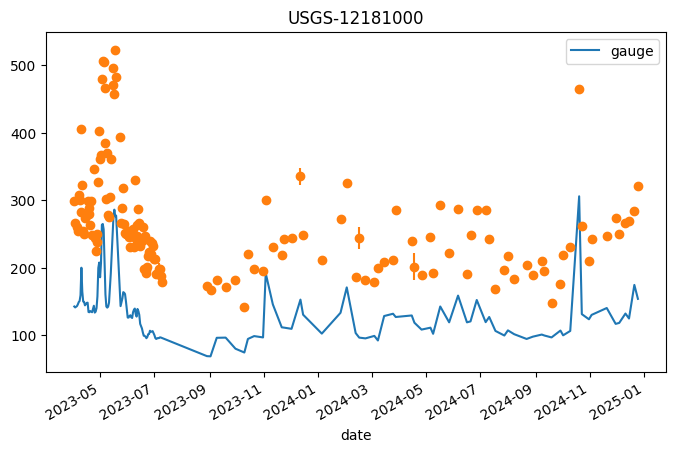

In [12]:
d = Path("/nas/cee-water/cjgleason/ted/swot-ml/notebooks/multigraph_manual/tests/timeseries")
d.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8,5))

gauge_id = 'USGS-12181000'
gauge_results = results[results['subbasin'] == gauge_id].copy()
gauge_results['date'] = pd.to_datetime(gauge_results['date'])

gauge_results.plot('date','y', ax=ax, label='gauge')
# gauge_results.plot('date','y_pred', ax=ax, label='model')
ax.errorbar(gauge_results['date'], gauge_results['y_pred'], yerr=gauge_results['y_pred_std'], fmt='o', label='model')
ax.set_title(gauge_id)

fig.autofmt_xdate()
fig.savefig(d / f"{gauge_id}.png", dpi=300)

In [59]:
gauge_results

,subbasin,date,y,y_pred
60,USGS-12181000,2023-11-11T00:00:00.000000000,145.548599,132.549042
93,USGS-12181000,2023-08-29T00:00:00.000000000,68.809921,88.413940
217,USGS-12181000,2023-06-15T00:00:00.000000000,116.665421,118.448868
268,USGS-12181000,2023-06-07T00:00:00.000000000,133.938675,139.172714
364,USGS-12181000,2023-05-07T00:00:00.000000000,160.273285,178.836151
...,...,...,...,...
32027,USGS-12181000,2024-02-12T00:00:00.000000000,103.073341,121.034714
32029,USGS-12181000,2024-01-05T00:00:00.000000000,102.223801,108.139198
32348,USGS-12181000,2024-05-27T00:00:00.000000000,118.930733,158.886215
33294,USGS-12181000,2023-05-18T00:00:00.000000000,276.089111,243.060822


In [28]:
import geopandas as gpd 
gauges = gpd.read_parquet("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph_manual/metadata/gauges.parquet")
gauges.index = gauges['site_id'].astype(str)

In [54]:
kge_gdf = gauges.merge(kge.rename('kge').dropna(), left_index=True, right_index=True, how='inner')
kge_gdf

,name,area,active,latitude,longitude,last_updated,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider_misc,geometry,provider,site_id,COMID,position,terminal_site_id,kge
EAUF-51430001,La Tapanahoni; Tapanahoni supérieure à Grand-S...,NaN,True,4.226223,-54.544087,2025-09-09,2021-10-20,2025-09-04,11.5150,2952.411,763.618689,1338.0,None,POINT (-54.54602 4.22815),eauf,EAUF-51430001,61031906,0.659495,EAUF-50410001,0.943697
EAUF-52200001,Le Maroni [Lawa] à Maripasoula [Taluen],NaN,True,3.384284,-54.052141,2025-09-09,2015-01-22,2025-09-07,19.1040,2191.500,530.355714,3667.0,None,POINT (-54.05214 3.38583),eauf,EAUF-52200001,61036407,0.419025,EAUF-50410001,0.920339
EAUF-52210001,Le Maroni [Le Lawa] à Maripasoula,NaN,True,3.647586,-54.024466,2025-09-09,1953-12-30,2025-09-02,9.5390,3704.867,784.964430,24744.0,None,POINT (-54.02344 3.64656),eauf,EAUF-52210001,61036263,0.395388,EAUF-50410001,0.877205
EAUF-52210002,Le Maroni [Lawa] à Papaichton,NaN,True,3.805435,-54.142595,2025-09-09,2016-02-25,2025-09-08,22.0500,3773.343,925.248935,3472.0,None,POINT (-54.1426 3.80333),eauf,EAUF-52210002,61031762,0.389544,EAUF-50410001,0.920670
EAUF-52410001,Le Maroni [Le Lawa] à Grand-Santi,NaN,True,4.271527,-54.381601,2025-09-09,1953-08-01,2025-09-08,14.7200,4264.530,974.645912,13096.0,None,POINT (-54.38281 4.27031),eauf,EAUF-52410001,61031743,0.052387,EAUF-50410001,0.918317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BRANA-86879300,ESTRELA,22472.0,False,-29.473300,-51.962200,2025-11-06,2020-11-25,2023-12-31,414.9800,17260.900,1231.556490,1063.0,None,POINT (-51.96317 -29.47233),brana,BRANA-86879300,64054811,0.453002,BRANA-86879300,0.836580
BRANA-87150000,LINHA GONZAGA,1350.0,False,-29.307500,-50.995800,2025-11-06,2010-01-28,2025-06-30,1.0154,975.206,24.840869,5534.0,None,POINT (-50.99583 -29.3075),brana,BRANA-87150000,64055233,0.387486,BRANA-87170000,0.669158
BRANA-87170000,BARCA DO CAÍ,3030.0,False,-29.590000,-51.383300,2025-11-06,1978-01-01,2025-06-30,1.3103,1346.000,69.877739,17202.0,None,POINT (-51.38373 -29.58957),brana,BRANA-87170000,64061566,0.618578,BRANA-87170000,0.933108
BRANA-87670000,PASSO DAS CARRETAS,7540.0,False,-30.973300,-53.046100,2025-11-06,2000-01-21,2025-06-30,0.3905,3238.320,160.323301,9051.0,None,POINT (-53.0475 -30.97417),brana,BRANA-87670000,64060566,0.115806,BRANA-87905000,0.985894


<Axes: >

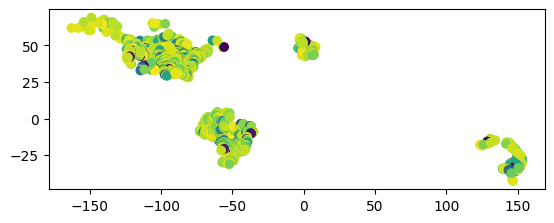

In [57]:
kge_gdf.plot('kge', vmin=0, vmax=1)